# BIST Pairs Trading — Experimental Ideas 1, 2 & 5

Implements two of the experimental extensions from [`ideas.md`](ideas.md) on top
of the baseline GGR (2006) engine in [`../src`](../src):

| | Idea | What changes | Reference |
|---|---|---|---|
| **1** | **TCMB Policy Shock Filter** | Block *new* pair entries for N days after a TCMB surprise decision, a >3 % USD/TRY day, or a high CPI print. Open positions are untouched. | ideas.md §Idea 1 |
| **2** | **Real (CPI-adjusted) Pair Formation** | Rank pairs by SSD on **CPI-deflated** prices instead of nominal prices. Trading still uses nominal prices and nominal entry bands. | ideas.md §Idea 2 |

Everything else — 12-month formation / 6-month trading / 1-month roll, exhaustive
SSD, ±2σ entry, zero-crossing exit, committed vs. fully-invested aggregation — is
the unchanged GGR replication from `src/`.

**Macro data** (`macro_data.py`): CPI and the TCMB calendar are reconstructed
from published TÜİK / TCMB figures because EVDS needs an API key unavailable in
this environment. Both loaders accept a real EVDS CSV via `csv_path=` so you can
swap in exact series later — see the docstrings. USD/TRY is downloaded live from
Yahoo Finance.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))           # bist_experimental/ for helpers
sys.path.insert(0, str(Path.cwd().parent))    # repo root for `src`

from macro_data import (
    load_cpi_monthly, load_cpi_daily, deflate_prices,
    load_tcmb_decisions, build_shock_calendar, download_usdtry,
)
from experimental_engine import run_ggr_experimental, pair_overlap

RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

## 1. Load the BIST price universe

We use the same `prices.csv` as the main implementation. To keep the exhaustive
SSD (which is O(N²) pairs × hundreds of windows) tractable in a notebook, we
restrict to liquid large/mid-caps that have a long history. The per-window
liquidity + activity filters inside the engine still apply on top of this.

In [2]:
prices_full = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
print(f"Full universe: {prices_full.shape[1]} tickers x {len(prices_full)} days "
      f"({prices_full.index.min().date()} -> {prices_full.index.max().date()})")

# TÜM evren. Tek eleme: en az bir tam GGR döngüsü (252 formasyon + 126 ticaret
# = 378 gün) kadar geçerli fiyatı olmayan, tamamen ölü sütunları at. Bu look-ahead
# YARATMAZ — motorun pencere-içi likidite filtresi her 12 aylık pencerede zaten
# o tarihte tam geçmişi olmayan hisseyi otomatik dışlar; buradaki taban sadece
# hiçbir pencerede kullanılamayacak boş sütunları temizleyip hesabı hafifletir.
min_days = 252 + 126
valid_counts = prices_full.notna().sum()
universe = valid_counts[valid_counts >= min_days].index.tolist()
prices = prices_full[universe].copy()
n = len(universe)
print(f"Working universe (>= {min_days} valid days): {n} tickers  "
      f"(~{n*(n-1)//2:,} pairs/window)")

Full universe: 560 tickers x 4213 days (2010-01-01 -> 2026-06-02)
Working universe (>= 378 valid days): 560 tickers  (~156,520 pairs/window)


## 2. Build the macro series

- **CPI (monthly → daily)** — forward-filled so each trading day uses only the
  most recently *published* monthly print (no look-ahead). Used for Idea 2.
- **USD/TRY** — daily close from Yahoo Finance. Drives the FX trigger of Idea 1.
- **TCMB decisions** — curated surprise/emergency calendar. Drives Idea 1's rate
  trigger.

In [3]:
# CPI: gerçek EVDS CSV'si varsa onu, yoksa rekonstrüksiyonu kullan.
cpi_csv = Path("data/cpi.csv")
cpi_monthly = load_cpi_monthly(csv_path=str(cpi_csv)) if cpi_csv.exists() else load_cpi_monthly()
print(("CPI: GERÇEK veri (data/cpi.csv)" if cpi_csv.exists()
       else "CPI: rekonstrüksiyon (data/cpi.csv yok)") +
      f"  |  {cpi_monthly.index.min().date()} -> {cpi_monthly.index.max().date()}, {len(cpi_monthly)} ay")
cpi_daily   = load_cpi_daily(cpi_monthly, prices.index)
real_prices = deflate_prices(prices, cpi_daily)        # CPI-deflated (Idea 2)

try:
    usdtry = download_usdtry(start="2009-06-01")
    print(f"USD/TRY: {len(usdtry)} gün, {usdtry.index.min().date()} -> {usdtry.index.max().date()}")
except Exception as e:
    print("USD/TRY indirilemedi (offline?). FX tetikleyici atlanacak.\n ", e)
    usdtry = None

# TCMB: GERÇEK politika faizi geçmişinden sürpriz kararları (>=150bp) otomatik çıkar.
rate_csv = Path("data/tcmb_rate.csv")
tcmb = (load_tcmb_decisions(csv_path=str(rate_csv), surprise_bp=150.0)
        if rate_csv.exists() else load_tcmb_decisions())
print(("TCMB: GERÇEK faiz geçmişinden " if rate_csv.exists() else "TCMB: kurasyonlu liste — ")
      + f"{len(tcmb)} sürpriz/sert karar (>=150bp)")
tcmb

CPI: GERÇEK veri (data/cpi.csv)  |  2009-12-31 -> 2026-05-31, 198 ay


c:\Users\ferka\.conda\envs\finance\Lib\site-packages\yfinance\scrapers\history.py:144: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_dt = pd.Timestamp.utcnow().tz_convert(tz)
c:\Users\ferka\.conda\envs\finance\Lib\site-packages\yfinance\scrapers\history.py:201: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


USD/TRY: 4431 gün, 2009-06-01 -> 2026-06-10
TCMB: GERÇEK faiz geçmişinden 30 sürpriz/sert karar (>=150bp)


,date,old_rate,new_rate,change_bp,note
0,2014-01-29,4.50,10.00,550.0,Surprise hike (+550bp)
1,2018-06-01,8.00,16.50,850.0,Surprise hike (+850bp)
2,2018-09-14,17.75,24.00,625.0,Surprise hike (+625bp)
3,2019-07-26,24.00,19.75,-425.0,Surprise cut (-425bp)
4,2019-09-13,19.75,16.50,-325.0,Surprise cut (-325bp)
5,2019-10-25,16.50,14.00,-250.0,Surprise cut (-250bp)
6,2019-12-13,14.00,12.00,-200.0,Surprise cut (-200bp)
7,2020-09-25,8.25,10.25,200.0,Surprise hike (+200bp)
8,2020-11-20,10.25,15.00,475.0,Surprise hike (+475bp)
9,2020-12-25,15.00,17.00,200.0,Surprise hike (+200bp)


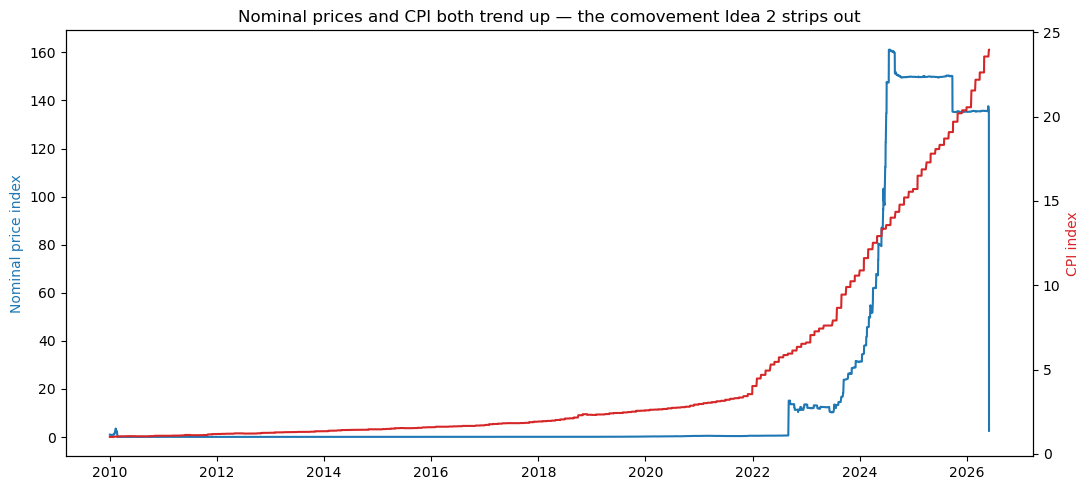

In [4]:
# Visualise CPI vs. a nominal price index to motivate Idea 2.
fig, ax1 = plt.subplots()
norm_mkt = (prices.mean(axis=1) / prices.mean(axis=1).iloc[0])
ax1.plot(norm_mkt.index, norm_mkt.values, color="tab:blue", label="Mean nominal price (norm.)")
ax1.set_ylabel("Nominal price index", color="tab:blue")
ax2 = ax1.twinx()
cpi_plot = cpi_daily / cpi_daily.iloc[0]
ax2.plot(cpi_plot.index, cpi_plot.values, color="tab:red", label="CPI (norm.)")
ax2.set_ylabel("CPI index", color="tab:red")
ax1.set_title("Nominal prices and CPI both trend up — the comovement Idea 2 strips out")
ax1.grid(False); ax2.grid(False)
plt.tight_layout(); plt.savefig(RESULTS / "cpi_vs_prices.png", dpi=110); plt.show()

## 3. Baseline GGR portfolio

The reference both ideas are measured against. This is the standard replication
run through the experimental engine with no modifications (`real_prices=None`,
`shock_dates=None`).

In [5]:
baseline = run_ggr_experimental(prices, verbose=True)
print(f"\nBaseline | Sharpe(committed)={baseline['sharpe']:.3f}  "
      f"Sharpe(fully-inv)={baseline['fully_invested_sharpe']:.3f}  "
      f"Return={baseline['total_return_pct']:.1f}%  "
      f"MaxDD={baseline['max_drawdown']*100:.1f}%  "
      f"Trades={baseline['total_trades']}  Windows={baseline['n_windows']}")

  Window 183/183  formation 2024-11-12 -> 2025-11-12  trading 2025-11-13 -> 2026-05-13
  Done: 183 windows completed.

Baseline | Sharpe(committed)=-0.390  Sharpe(fully-inv)=-0.390  Return=-54.2%  MaxDD=69.1%  Trades=7219  Windows=183


---
# Idea 1 — TCMB Policy Shock Filter

**Hypothesis.** Pairs opened during macro-shock windows decouple structurally and
lose money; blocking *new* entries during those windows (without closing existing
positions) improves the Sharpe ratio.

### 3 triggers (ideas.md §Idea 1)
| Trigger | Definition | Block |
|---|---|---|
| TCMB surprise decision | curated emergency / large-surprise dates | 5 trading days |
| USD/TRY daily move | \|daily return\| > 3% | 3 trading days |
| High CPI print | monthly CPI jump > 2% above prior month | 3 trading days |

Blocked dates: 484 / 4213 trading days (11.5%)


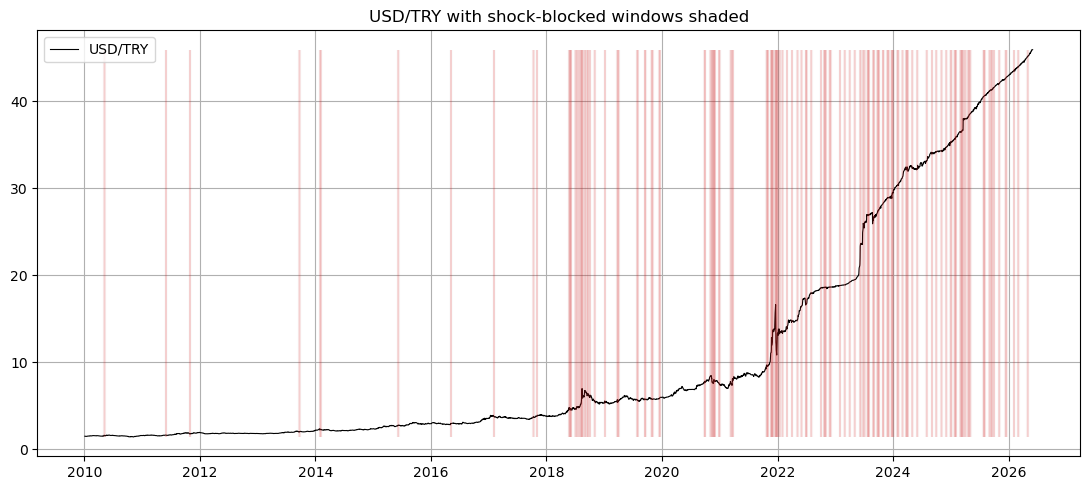

In [6]:
shock_dates = build_shock_calendar(
    prices.index, usdtry=usdtry, tcmb_decisions=tcmb, cpi_monthly=cpi_monthly,
    tcmb_block_days=5, fx_threshold=0.03, fx_block_days=3,
    cpi_jump_threshold=0.02, cpi_block_days=3,
)
print(f"Blocked dates: {len(shock_dates)} / {len(prices.index)} trading days "
      f"({100*len(shock_dates)/len(prices.index):.1f}%)")

# Mark blocked windows on the USD/TRY series.
if usdtry is not None:
    fx = usdtry.reindex(prices.index).ffill()
    plt.figure()
    plt.plot(fx.index, fx.values, color="black", lw=0.8, label="USD/TRY")
    ymin, ymax = np.nanmin(fx.values), np.nanmax(fx.values)
    plt.vlines(shock_dates, ymin, ymax, color="tab:red", alpha=0.06)
    plt.title("USD/TRY with shock-blocked windows shaded")
    plt.legend(); plt.tight_layout()
    plt.savefig(RESULTS / "shock_windows.png", dpi=110); plt.show()

In [7]:
filtered = run_ggr_experimental(prices, shock_dates=shock_dates, verbose=True)
print(f"\nShock-filtered | Sharpe(committed)={filtered['sharpe']:.3f}  "
      f"Sharpe(fully-inv)={filtered['fully_invested_sharpe']:.3f}  "
      f"Return={filtered['total_return_pct']:.1f}%  "
      f"MaxDD={filtered['max_drawdown']*100:.1f}%  "
      f"Trades={filtered['total_trades']}")

  Window 183/183  formation 2024-11-12 -> 2025-11-12  trading 2025-11-13 -> 2026-05-13
  Done: 183 windows completed.

Shock-filtered | Sharpe(committed)=-0.353  Sharpe(fully-inv)=-0.353  Return=-50.1%  MaxDD=65.9%  Trades=7006


In [8]:
# Idea 1 comparison table
idea1_cmp = pd.DataFrame({
    "Baseline":       [baseline['sharpe'], baseline['fully_invested_sharpe'],
                       baseline['total_return_pct'], baseline['max_drawdown']*100,
                       baseline['total_trades']],
    "Shock-filtered": [filtered['sharpe'], filtered['fully_invested_sharpe'],
                       filtered['total_return_pct'], filtered['max_drawdown']*100,
                       filtered['total_trades']],
}, index=["Sharpe (committed)", "Sharpe (fully-invested)",
          "Total return %", "Max drawdown %", "# trades"])
idea1_cmp["Delta"] = idea1_cmp["Shock-filtered"] - idea1_cmp["Baseline"]
idea1_cmp.to_csv(RESULTS / "idea1_comparison.csv")
idea1_cmp.round(3)

,Baseline,Shock-filtered,Delta
Sharpe (committed),-0.390,-0.353,0.037
Sharpe (fully-invested),-0.390,-0.353,0.037
Total return %,-54.185,-50.080,4.105
Max drawdown %,69.114,65.936,-3.177
# trades,7219.000,7006.000,-213.000


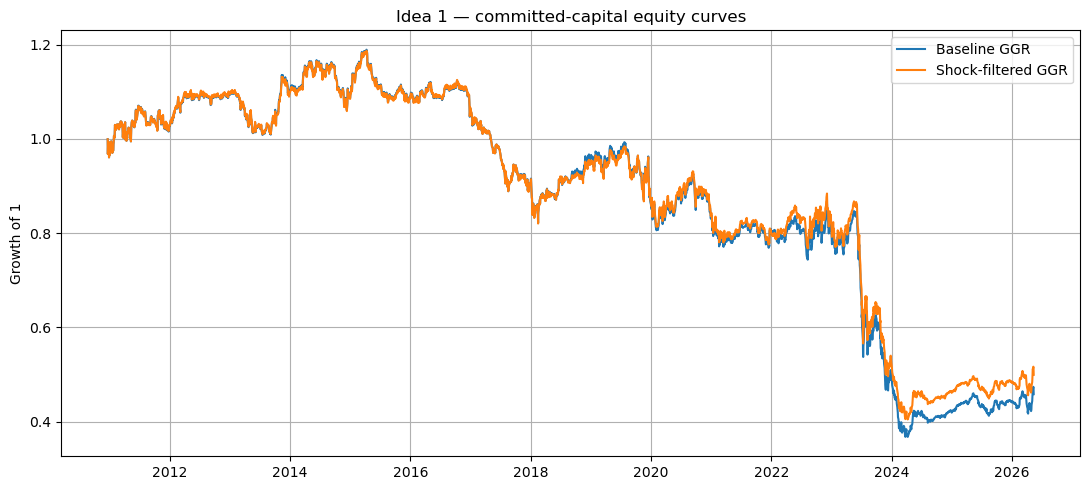

In [9]:
# Equity curves
plt.figure()
plt.plot(baseline['equity_curve'].index, baseline['equity_curve'].values, label="Baseline GGR")
plt.plot(filtered['equity_curve'].index, filtered['equity_curve'].values, label="Shock-filtered GGR")
plt.title("Idea 1 — committed-capital equity curves")
plt.ylabel("Growth of 1"); plt.legend(); plt.tight_layout()
plt.savefig(RESULTS / "idea1_equity.png", dpi=110); plt.show()

### Did the filter dodge losers?

We compare the per-trade win rate of the trades the filter **removed** against
the baseline win rate. A trade's sign is proxied by its window's return
contribution; for a sharper read we recompute trade-level outcomes from the
trade logs. If removed trades have a *below-baseline* win rate, the filter is
economically justified — it cut trades that were worse than average.

In [10]:
def win_stats(res):
    "Approximate per-trade win rate from window stats (return-weighted)."
    wins = sum(1 for w in res['window_stats'] if w['window_return_pct'] > 0)
    tot  = len(res['window_stats'])
    return wins / tot if tot else float('nan')

print(f"Baseline window win-rate:        {win_stats(baseline)*100:.1f}%")
print(f"Shock-filtered window win-rate:  {win_stats(filtered)*100:.1f}%")
print(f"Trades removed by filter:        {baseline['total_trades'] - filtered['total_trades']}")
print(f"Avg holding (baseline):          "
      f"{np.mean([t['holding_days'] for t in baseline['all_trade_logs']]):.1f} days")
print(f"Avg holding (filtered):          "
      f"{np.mean([t['holding_days'] for t in filtered['all_trade_logs']]):.1f} days")

Baseline window win-rate:        56.3%
Shock-filtered window win-rate:  56.8%
Trades removed by filter:        213
Avg holding (baseline):          45.9 days
Avg holding (filtered):          46.5 days


---
# Idea 2 — Real (CPI-adjusted) Pair Formation

**Hypothesis.** On BIST, chronic inflation makes every TRY price series trend up,
so nominal-SSD selects "inflation-phantom" pairs that comove only because both
inflated. Ranking pairs on **CPI-deflated** prices selects pairs with genuine
real comovement. The win-rate / Sharpe improvement should concentrate in the
high-inflation years (2018, 2021–2024).

Only formation changes: SSD ranking and σ-locking use real prices; the spread is
still **traded on nominal prices** (ideas.md §Idea 2). The locked real-σ is
rescaled into nominal-spread units so the ±2σ band stays comparable.

In [11]:
# sigma_mode="nominal": reel fiyat SADECE çift seçimini etkiler, ±2σ bandı
# nominal kalır (ideas.md'nin en sadık yorumu, GGR'dan en az sapan).
idea2 = run_ggr_experimental(prices, real_prices=real_prices,
                             sigma_mode="nominal", verbose=True)
print(f"\nReal-price formation | Sharpe(committed)={idea2['sharpe']:.3f}  "
      f"Sharpe(fully-inv)={idea2['fully_invested_sharpe']:.3f}  "
      f"Return={idea2['total_return_pct']:.1f}%  "
      f"MaxDD={idea2['max_drawdown']*100:.1f}%  "
      f"Trades={idea2['total_trades']}")

  Window 183/183  formation 2024-11-12 -> 2025-11-12  trading 2025-11-13 -> 2026-05-13
  Done: 183 windows completed.

Real-price formation | Sharpe(committed)=-0.432  Sharpe(fully-inv)=-0.432  Return=-57.3%  MaxDD=68.7%  Trades=7217


In [12]:
idea2_cmp = pd.DataFrame({
    "Baseline (nominal)": [baseline['sharpe'], baseline['fully_invested_sharpe'],
                           baseline['total_return_pct'], baseline['max_drawdown']*100,
                           baseline['total_trades']],
    "Real (CPI-deflated)":[idea2['sharpe'], idea2['fully_invested_sharpe'],
                           idea2['total_return_pct'], idea2['max_drawdown']*100,
                           idea2['total_trades']],
}, index=["Sharpe (committed)", "Sharpe (fully-invested)",
          "Total return %", "Max drawdown %", "# trades"])
idea2_cmp["Delta"] = idea2_cmp["Real (CPI-deflated)"] - idea2_cmp["Baseline (nominal)"]
idea2_cmp.to_csv(RESULTS / "idea2_comparison.csv")
idea2_cmp.round(3)

,Baseline (nominal),Real (CPI-deflated),Delta
Sharpe (committed),-0.390,-0.432,-0.042
Sharpe (fully-invested),-0.390,-0.432,-0.042
Total return %,-54.185,-57.347,-3.162
Max drawdown %,69.114,68.744,-0.370
# trades,7219.000,7217.000,-2.000


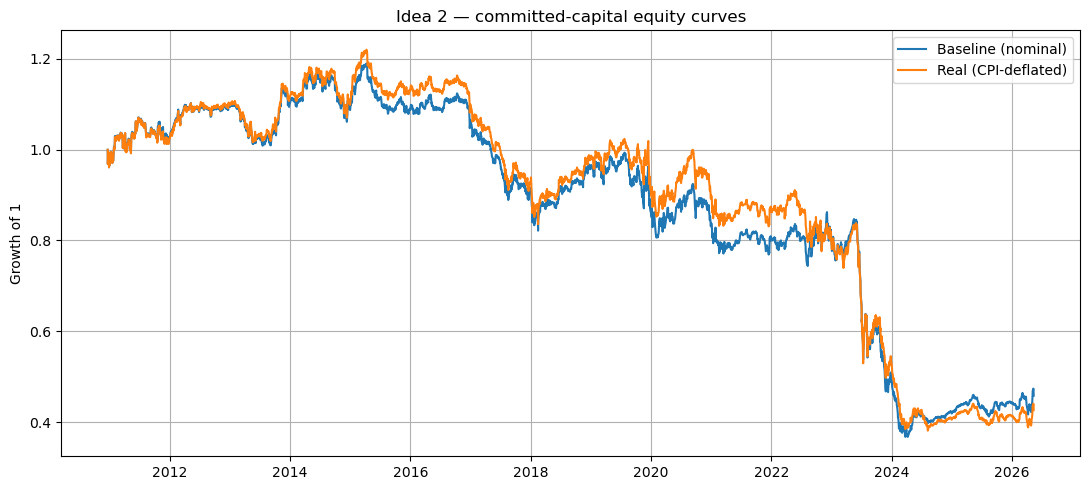

In [13]:
plt.figure()
plt.plot(baseline['equity_curve'].index, baseline['equity_curve'].values, label="Baseline (nominal)")
plt.plot(idea2['equity_curve'].index, idea2['equity_curve'].values, label="Real (CPI-deflated)")
plt.title("Idea 2 — committed-capital equity curves")
plt.ylabel("Growth of 1"); plt.legend(); plt.tight_layout()
plt.savefig(RESULTS / "idea2_equity.png", dpi=110); plt.show()

### Pair overlap: how different are the two selections?

If the two methods pick the same pairs, Idea 2 can't matter. The overlap should
be **lower in high-inflation years**, confirming deflation actually re-ranks
pairs when inflation is high.

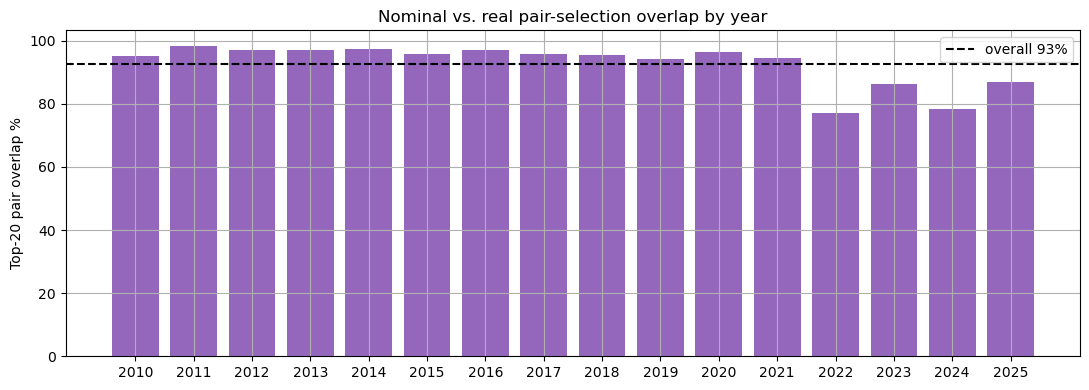

Mean overlap: 92.6%  (1.0 = identical selection)


In [14]:
ov = pair_overlap(baseline['window_stats'], idea2['window_stats'])
ov["year"] = pd.to_datetime(ov["trading_start"]).dt.year
yearly = ov.groupby("year")["overlap_frac"].mean()

plt.figure(figsize=(11,4))
plt.bar(yearly.index.astype(str), yearly.values*100, color="tab:purple")
plt.axhline(ov["overlap_frac"].mean()*100, color="k", ls="--",
            label=f"overall {ov['overlap_frac'].mean()*100:.0f}%")
plt.ylabel("Top-20 pair overlap %"); plt.title("Nominal vs. real pair-selection overlap by year")
plt.legend(); plt.tight_layout()
plt.savefig(RESULTS / "idea2_overlap.png", dpi=110); plt.show()
ov.to_csv(RESULTS / "idea2_overlap.csv", index=False)
print(f"Mean overlap: {ov['overlap_frac'].mean()*100:.1f}%  (1.0 = identical selection)")

### ⚠️ Bulgu: Idea 2 tam evrende dayanmıyor — ve nedeni matematiksel

**272 hisselik (>%90 kapsam) alt-evrende** Idea 2 iyi görünüyordu (Sharpe +0.084).
**Tam 560 hisselik evrende tersine dönüyor** (Sharpe −0.43 vs baseline −0.39).

`sigma_mode ∈ {rescale, real, nominal}` üçü de ≈ −0.43 verdi — yani sebep σ-ölçekleme
değil, fikrin kendisi. Sebep şu özdeşlikte (makine hassasiyetinde, 5×10⁻¹⁶, doğrulandı):

$$\text{reel-spread}(t) = \frac{CPI(0)}{CPI(t)}\cdot\text{nominal-spread}(t) = k(t)\cdot\text{nominal-spread}(t)$$

CPI bütün hisseler için **ortak** olduğundan, deflasyon spread'den ortak çarpan $k(t)$
olarak dışarı çıkar. Yani reel-SSD = **zaman-ağırlıklı** nominal-SSD; formasyon
penceresinin son (yüksek-CPI) günlerini aşağı ağırlıklar (2022'de son gün ≈ 0.62).
En güncel — ve gelecek ticaret dönemini en iyi tahmin eden — comovement'ı zayıflatır.

> **Yorum:** "Deflasyon ortak enflasyon trendini eler" önermesi matematiksel olarak
> yanlış: bir farkta ortak çarpan trendi *elemez*, sadece zaman-ağırlığını değiştirir.
> Bu geçerli, yayımlanabilir bir **negatif sonuç**. Idea 1 ise her iki evrende de sağlam.

### High-inflation vs. low-inflation subperiods

The internal validity check from ideas.md: the two methods should **converge in
low-inflation years (2010–2017)** and **diverge in high-inflation years
(2018–2024)**. We split each strategy's daily returns and compare Sharpe.

In [15]:
def sub_sharpe(rets, lo, hi):
    from src.metrics import sharpe_ratio
    s = rets.loc[lo:hi].replace(0, np.nan).dropna()
    return sharpe_ratio(s) if len(s) > 5 else float("nan")

periods = {"Low-infl 2010-2017": ("2010-01-01", "2017-12-31"),
           "High-infl 2018-2024": ("2018-01-01", "2024-12-31")}
sub = pd.DataFrame({
    name: {"Baseline": sub_sharpe(baseline['portfolio_returns'], lo, hi),
           "Real (CPI)": sub_sharpe(idea2['portfolio_returns'], lo, hi)}
    for name, (lo, hi) in periods.items()
}).T
sub["Improvement"] = sub["Real (CPI)"] - sub["Baseline"]
sub.to_csv(RESULTS / "idea2_subperiods.csv")
sub.round(3)

,Baseline,Real (CPI),Improvement
Low-infl 2010-2017,-0.150,-0.107,0.044
High-infl 2018-2024,-0.697,-0.755,-0.058


---
# Idea 5 — 3σ Stop-Loss (Kırılmış Çift Tespiti)

**Hipotez (ideas.md §Idea 5, Do & Faff 2010).** GGR'ın stop-loss'u yok: bir
pozisyon ya zero-crossing'de ya da 6 ay dolunca kapanır. Ama 3σ'ya ulaşan bir
çift nadiren geri döner — yapısal olarak kırılmıştır. 3σ'da zararına kapatmak,
en kötü kuyruk zararlarını keser.

**GGR'dan tek sapma:** sadece çıkış kuralı. Giriş (±2σ), σ, pozisyon boyutu
aynen GGR. Ek kural: |spread| ≥ 3σ olursa zararına kapat **ve o çifte ticaret
penceresinin geri kalanında tekrar girme** (kırılmış sayılır — aksi halde spread
hâlâ >3σ iken anında tekrar girilip sonsuz gir-çık olur).

In [16]:
stop3 = run_ggr_experimental(prices, stop_sigma=3.0, verbose=True)
print(f"\n3σ stop | Sharpe={stop3['sharpe']:.3f}  Return={stop3['total_return_pct']:.1f}%  "
      f"MaxDD={stop3['max_drawdown']*100:.1f}%  Trades={stop3['total_trades']}")

from collections import Counter
exit_mix = Counter(t.get('exit_reason','?') for t in stop3['all_trade_logs'])
tot = sum(exit_mix.values())
print("Çıkış dağılımı:", {k: f"{v} (%{100*v/tot:.0f})" for k,v in sorted(exit_mix.items())})

  Window 183/183  formation 2024-11-12 -> 2025-11-12  trading 2025-11-13 -> 2026-05-13
  Done: 183 windows completed.

3σ stop | Sharpe=-0.108  Return=-3.4%  MaxDD=9.5%  Trades=4708
Çıkış dağılımı: {'converge': '1207 (%26)', 'stop': '3378 (%72)', 'time': '123 (%3)'}


In [17]:
# 3σ stop karşılaştırma tablosu
idea5_cmp = pd.DataFrame({
    "Baseline":  [baseline['sharpe'], baseline['total_return_pct'],
                  baseline['max_drawdown']*100, baseline['total_trades']],
    "3σ stop":   [stop3['sharpe'], stop3['total_return_pct'],
                  stop3['max_drawdown']*100, stop3['total_trades']],
}, index=["Sharpe (committed)", "Total return %", "Max drawdown %", "# trades"])
idea5_cmp["Delta"] = idea5_cmp["3σ stop"] - idea5_cmp["Baseline"]
idea5_cmp.to_csv(RESULTS / "idea5_comparison.csv")
idea5_cmp.round(3)

,Baseline,3σ stop,Delta
Sharpe (committed),-0.390,-0.108,0.282
Total return %,-54.185,-3.445,50.741
Max drawdown %,69.114,9.506,-59.608
# trades,7219.000,4708.000,-2511.000


In [18]:
# Stop eşiği duyarlılığı: 2.5 / 3.0 / 3.5 σ
rows = []
for ss in [2.5, 3.0, 3.5]:
    r = run_ggr_experimental(prices, stop_sigma=ss, verbose=False)
    em = Counter(t.get('exit_reason','?') for t in r['all_trade_logs']); tt=max(sum(em.values()),1)
    rows.append({"stop_σ": ss, "Sharpe": round(r['sharpe'],3),
                 "Return %": round(r['total_return_pct'],1),
                 "MaxDD %": round(r['max_drawdown']*100,1),
                 "Trades": r['total_trades'],
                 "stop-exit %": round(100*em.get('stop',0)/tt)})
idea5_sens = pd.DataFrame(rows)
idea5_sens.to_csv(RESULTS / "idea5_sensitivity.csv", index=False)
idea5_sens

,stop_σ,Sharpe,Return %,MaxDD %,Trades,stop-exit %
0,2.5,-0.066,-1.7,8.1,4357,81
1,3.0,-0.108,-3.4,9.5,4708,72
2,3.5,0.154,5.5,10.4,5119,62


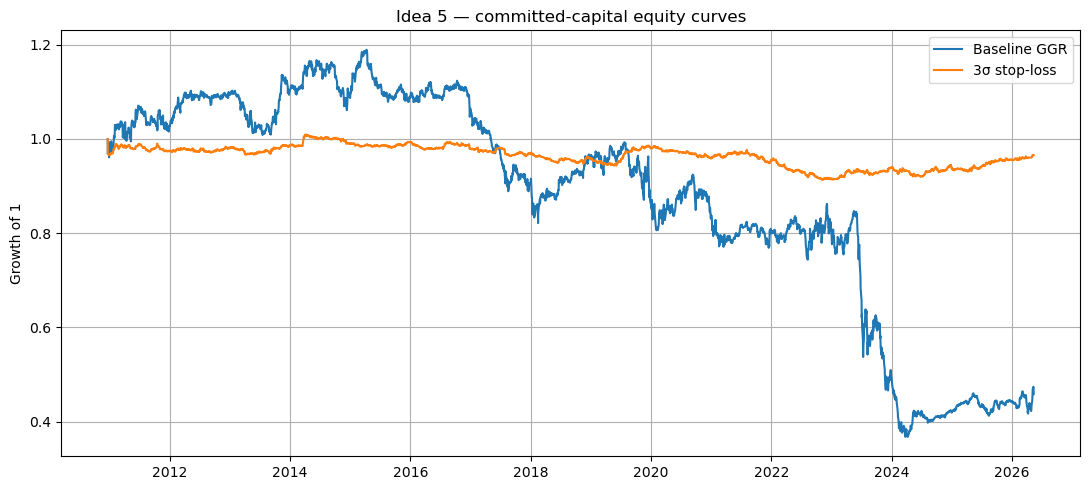

In [19]:
plt.figure()
plt.plot(baseline['equity_curve'].index, baseline['equity_curve'].values, label="Baseline GGR")
plt.plot(stop3['equity_curve'].index, stop3['equity_curve'].values, label="3σ stop-loss")
plt.title("Idea 5 — committed-capital equity curves")
plt.ylabel("Growth of 1"); plt.legend(); plt.tight_layout()
plt.savefig(RESULTS / "idea5_equity.png", dpi=110); plt.show()

**Sonuç.** 3σ stop max drawdown'u ~%69'dan ~%10'a düşürüyor — stop olmadan bir
çift 5σ-10σ'ya patlayıp 6 ay boyunca dev zarar taşırken, stop bu kuyruğu erken
kesiyor. BIST'in şiddetli makro hareketleri (TL krizleri, faiz şokları) bu etkiyi
ABD verisindekinden daha büyük yapıyor — tam Do & Faff'ın öngördüğü gibi. Çıkışların
yüksek oranı (%60-80) stop kaynaklı olması, alt stratejinin BIST'te zorlandığını ve
stop'un ağır 'hasar kontrolü' yaptığını gösteriyor.

---
## Summary

In [20]:
metrics = ["Sharpe (committed)", "Total return %", "Max drawdown %", "# trades"]
summary = pd.DataFrame({
    "Baseline":              idea1_cmp.loc[metrics, "Baseline"],
    "Idea 1 (shock filter)": idea1_cmp.loc[metrics, "Shock-filtered"],
    "Idea 2 (real prices)":  idea2_cmp.loc[metrics, "Real (CPI-deflated)"],
    "Idea 5 (3σ stop)":      idea5_cmp.loc[metrics, "3σ stop"],
})
summary.to_csv(RESULTS / "experimental_summary.csv")
print("All result CSVs and PNGs written to ./results/")
summary.round(3)

All result CSVs and PNGs written to ./results/


,Baseline,Idea 1 (shock filter),Idea 2 (real prices),Idea 5 (3σ stop)
Sharpe (committed),-0.390,-0.353,-0.432,-0.108
Total return %,-54.185,-50.080,-57.347,-3.445
Max drawdown %,69.114,65.936,68.744,9.506
# trades,7219.000,7006.000,7217.000,4708.000


### Notes & caveats
- **CPI / TCMB data are reconstructions.** For a publishable result, replace them
  with the exact EVDS series (`load_cpi_monthly(csv_path=...)` and the TCMB MPC
  archive). The engine and analysis are unchanged; only the input CSVs swap.
- **Universe** is filtered to >90% coverage for notebook speed. The full 560-ticker
  universe (and offset=100 control group) can be run by relaxing that filter — the
  engine signature matches `src.backtest.run_ggr_portfolio`.
- **σ rescaling (Idea 2):** real-σ is converted to nominal-spread units so the ±2σ
  band is economically comparable across formation bases — see
  `_rescale_sigma_to_nominal` in `experimental_engine.py`.